Olá, **Luisa Ayres**!

O meu nome é **César Malaguti** e sou o revisor do seu projeto. Quando identificar um erro pela primeira vez, apenas vou apontá-lo para que você mesmo possa encontrá-lo e corrigi-lo. Ao longo do notebook farei observações sobre as suas análises, sempre com o objetivo de te preparar para atuar como **Analista ou Cientista de Dados** no mercado. **Por favor, não mova, modifique ou exclua meus comentários.**

Você vai encontrar meus comentários em caixas coloridas:
<div class="alert alert-block alert-success"><b>Comentário do revisor (César Malaguti):</b> <a class="tocSkip"></a> Sucesso.</div>
<div class="alert alert-block alert-warning"><b>Comentário do revisor (César Malaguti):</b> <a class="tocSkip"></a> Atenção (sugestão).</div>
<div class="alert alert-block alert-danger"><b>Comentário do revisor (César Malaguti):</b> <a class="tocSkip"></a> Precisa de correção.</div>

Você pode me responder usando:
<div class="alert alert-block alert-info"><b>Resposta do Aluno.</b> <a class="tocSkip"></a></div>


<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

<b>Comentário geral:</b> Luisa, parabéns, **projeto APROVADO!** O projeto está completo e muito bem organizado em passos, o que facilita muito a leitura. Você preparou os dados, estudou o período coberto e filtrou o intervalo com registros completos, montou o **funil de eventos** com a conversão entre etapas e chegou à conversão total de **47,7%**.

Na parte experimental você foi além do básico: fez o **teste A/A** entre os dois grupos de controle, comparou o grupo experimental contra cada controle separadamente e também contra os dois combinados, e ainda aplicou a **correção de Bonferroni**, chegando ao alfa de 0,0025. Ótimo trabalho!
</div>

Este projeto tem como objetivo analisar o comportamento dos usuários em um aplicativo de uma startup de produtos alimentícios, utilizando dados de eventos registrados durante a interação dos clientes com a plataforma. A análise busca compreender a jornada dos usuários dentro do aplicativo, identificar oportunidades de melhoria no processo de compra e avaliar o impacto de uma possível alteração no design da interface.

Inicialmente, será realizada uma análise exploratória dos dados com o objetivo de compreender a estrutura do conjunto de dados, identificar possíveis inconsistências e garantir sua qualidade para as etapas seguintes da análise. Essa etapa envolverá processos de limpeza, tratamento, verificação de dados ausentes, duplicidades e validação das informações.

Após a leitura e inspeção das informações disponíveis, será calculado o número de eventos registrados, a quantidade de usuários presentes na base, o cálculo da média de eventos por usuário e a análise do período coberto pelos dados. Também será avaliada a distribuição temporal dos eventos para verificar se existem períodos com dados incompletos ou possíveis distorções causadas por registros antigos, garantindo que a análise seja realizada com dados representativos do comportamento dos usuários.

Após a preparação e validação dos dados, será analisado o funil de eventos do aplicativo. Essa etapa tem como objetivo compreender o caminho percorrido pelos usuários desde o primeiro contato com a plataforma até a conclusão da compra. Serão identificadas as principais etapas da jornada, a proporção de usuários que avançam entre cada fase e os pontos em que ocorre maior perda de usuários. Essa análise permitirá compreender quais etapas podem representar oportunidades de otimização para melhorar a conversão.

Na etapa final, serão realizados testes A/A/B para avaliar uma alteração proposta pela equipe de design: a mudança das fontes utilizadas no aplicativo. Como existe a possibilidade de que uma nova identidade visual afete a experiência dos usuários, a decisão sobre a implementação da mudança será baseada em testes estatísticos.

Nesse experimento, os usuários serão divididos em três grupos:

- Grupo 246: primeiro grupo de controle, utilizando a versão original do aplicativo;
- Grupo 247: segundo grupo de controle, também utilizando a versão original, utilizado para validar a divisão aleatória dos usuários e a confiabilidade do experimento;
- Grupo 248: grupo experimental, que recebeu a versão do aplicativo com as fontes alteradas.

Primeiramente, será realizada a comparação entre os dois grupos de controle (teste A/A) para verificar se eles apresentam comportamentos semelhantes. Essa validação é importante, pois garante que possíveis diferenças encontradas posteriormente entre o grupo experimental e os grupos de controle possam ser atribuídas à alteração da fonte, e não a diferenças pré-existentes entre os grupos.

Em seguida, será realizado o teste A/B comparando o grupo experimental com cada grupo de controle individualmente e também com os grupos de controle combinados. Para isso, serão aplicados testes estatísticos de hipótese utilizando as proporções de usuários que realizaram diferentes eventos do aplicativo. Além disso, será considerado o efeito das comparações múltiplas, ajustando o nível de significância quando necessário para reduzir o risco de falsos positivos.

Dessa forma, essa análise busca responder às seguintes perguntas principais:

- Como os usuários interagem com o aplicativo e quais etapas do funil de compra apresentam maior perda de usuários?
- Os grupos experimentais foram divididos corretamente e apresentam comportamento semelhante antes do teste?
- A alteração das fontes do aplicativo gerou algum impacto estatisticamente significativo no comportamento dos usuários e nas taxas de conversão?

Os resultados dessa análise fornecerão informações baseadas em dados para apoiar decisões de produto, indicando se a mudança visual deve ser implementada e quais pontos da jornada do usuário apresentam maior potencial de melhoria.

# Passo 1 - Abrindo o arquivo de dados para ler a informação geral

In [1]:
# Importando as bibliotecas
import matplotlib.pyplot as plt
import math
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats as st

In [2]:
# lendo o conjunto de dados do dataset logs
logs_df = pd.read_csv('/datasets/logs_exp_us.csv', sep='\t')
print(logs_df)

                      EventName         DeviceIDHash  EventTimestamp  ExpId
0              MainScreenAppear  4575588528974610257      1564029816    246
1              MainScreenAppear  7416695313311560658      1564053102    246
2       PaymentScreenSuccessful  3518123091307005509      1564054127    248
3              CartScreenAppear  3518123091307005509      1564054127    248
4       PaymentScreenSuccessful  6217807653094995999      1564055322    248
...                         ...                  ...             ...    ...
244121         MainScreenAppear  4599628364049201812      1565212345    247
244122         MainScreenAppear  5849806612437486590      1565212439    246
244123         MainScreenAppear  5746969938801999050      1565212483    246
244124         MainScreenAppear  5746969938801999050      1565212498    246
244125       OffersScreenAppear  5746969938801999050      1565212517    246

[244126 rows x 4 columns]


# Passo 2 - Preparando os dados para análise

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

Boa preparação: renomear as colunas para um padrão consistente, tratar duplicados e converter a coluna temporal antes de qualquer análise. Essa etapa parece burocrática, mas é ela que evita erro silencioso lá na frente.
</div>

In [3]:
# Imprimindo as 5 primeiras linhas do dataset logs
logs_df.head()

,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


In [4]:
# Imprimindo as 5 últimas linhas do dataset logs
logs_df.tail()

,EventName,DeviceIDHash,EventTimestamp,ExpId
244121,MainScreenAppear,4599628364049201812,1565212345,247
244122,MainScreenAppear,5849806612437486590,1565212439,246
244123,MainScreenAppear,5746969938801999050,1565212483,246
244124,MainScreenAppear,5746969938801999050,1565212498,246
244125,OffersScreenAppear,5746969938801999050,1565212517,246


In [5]:
# Imprimindo as informações do dataset logs e determinando o tamanho exato dos dados
logs_df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 22.9 MB


In [6]:
# Encontrando o número de valores únicos na coluna EventName do dataset logs e como elas são distribuídas
logs_df['EventName'].value_counts()

MainScreenAppear           119205
OffersScreenAppear          46825
CartScreenAppear            42731
PaymentScreenSuccessful     34313
Tutorial                     1052
Name: EventName, dtype: int64

In [7]:
# Convertendo a coluna EventName do dataset logs de object para category para economizar espaço
logs_df['EventName'] = logs_df['EventName'].astype('category')
logs_df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   EventName       244126 non-null  category
 1   DeviceIDHash    244126 non-null  int64   
 2   EventTimestamp  244126 non-null  int64   
 3   ExpId           244126 non-null  int64   
dtypes: category(1), int64(3)
memory usage: 5.8 MB


Podemos ver que a memória usada diminuiu muito (de 22.9 MB para 5.8 MB), já que transformou de object para category. 

In [8]:
# Convertendo a coluna DeviceIDHash do dataset logs de int64 para string 
logs_df['DeviceIDHash'] = logs_df['DeviceIDHash'].astype('str')
logs_df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   EventName       244126 non-null  category
 1   DeviceIDHash    244126 non-null  object  
 2   EventTimestamp  244126 non-null  int64   
 3   ExpId           244126 non-null  int64   
dtypes: category(1), int64(2), object(1)
memory usage: 21.6 MB


Podemos ver que a memória usada aumentou de novo (de 5.8 MB para 21.6 MB), devido à transformação de número inteiro para string, já que cada caractere numérico como texto ocupa mais espaço do que quando ele é armazenado como um número binário puro. 

In [9]:
# Encontrando o número de valores únicos na coluna ExpId do dataset logs e como elas são distribuídas
logs_df['ExpId'].value_counts()

248    85747
246    80304
247    78075
Name: ExpId, dtype: int64

In [10]:
# Convertendo a coluna ExpId do dataset logs de int64 para category
logs_df['ExpId'] = logs_df['ExpId'].astype('category')
logs_df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   EventName       244126 non-null  category
 1   DeviceIDHash    244126 non-null  object  
 2   EventTimestamp  244126 non-null  int64   
 3   ExpId           244126 non-null  category
dtypes: category(2), int64(1), object(1)
memory usage: 20.0 MB


Podemos ver que a memória usada diminuiu (de 21.6 MB para 20.0 MB), já que transformou de int64 para category.

In [11]:
# Imprimindo um resumo estatístico das colunas numéricas do dataset logs
logs_df.describe()

,EventTimestamp
count,2.441260e+05
mean,1.564914e+09
std,1.771343e+05
min,1.564030e+09
25%,1.564757e+09
50%,1.564919e+09
75%,1.565075e+09
max,1.565213e+09


In [12]:
# Mostrando o número de linhas e colunas do dataset logs
logs_df.shape

(244126, 4)

In [13]:
# Mostrando o nome das colunas do dataset logs
logs_df.columns

Index(['EventName', 'DeviceIDHash', 'EventTimestamp', 'ExpId'], dtype='object')

In [14]:
# Substituindo os nomes das colunas do dataset logs
logs_df = logs_df.rename(columns={'EventName': 'event_name', 'DeviceIDHash': 'user_id', 'EventTimestamp': 'event_timestamp', 'ExpId': 'exp_id'})
print(logs_df)

                     event_name              user_id  event_timestamp exp_id
0              MainScreenAppear  4575588528974610257       1564029816    246
1              MainScreenAppear  7416695313311560658       1564053102    246
2       PaymentScreenSuccessful  3518123091307005509       1564054127    248
3              CartScreenAppear  3518123091307005509       1564054127    248
4       PaymentScreenSuccessful  6217807653094995999       1564055322    248
...                         ...                  ...              ...    ...
244121         MainScreenAppear  4599628364049201812       1565212345    247
244122         MainScreenAppear  5849806612437486590       1565212439    246
244123         MainScreenAppear  5746969938801999050       1565212483    246
244124         MainScreenAppear  5746969938801999050       1565212498    246
244125       OffersScreenAppear  5746969938801999050       1565212517    246

[244126 rows x 4 columns]


In [15]:
# Verificando se há valores ausentes no dataset logs
logs_df.isna().sum()

event_name         0
user_id            0
event_timestamp    0
exp_id             0
dtype: int64

Não há valores ausentes no dataset logs.

In [16]:
# Verificando se há linhas completamente duplicadas no dataset logs
logs_df.duplicated().sum()

413

Há 413 linhas duplicadas em um total de 244126 no dataset logs, o que representa menos de 0,2%. Como todas as colunas dessas linhas são idênticas (evento, usuário, timestamp e experimento), concluí que eram duplicações da coleta dos dados e não novos eventos. Dessa forma, é necessário remover esses registros, utilizando drop_duplicates(), para garantir que as análises não sejam distorcidas.

In [17]:
# Removendo os duplicados do dataset logs
logs_df = logs_df.drop_duplicates()
print(logs_df)

                     event_name              user_id  event_timestamp exp_id
0              MainScreenAppear  4575588528974610257       1564029816    246
1              MainScreenAppear  7416695313311560658       1564053102    246
2       PaymentScreenSuccessful  3518123091307005509       1564054127    248
3              CartScreenAppear  3518123091307005509       1564054127    248
4       PaymentScreenSuccessful  6217807653094995999       1564055322    248
...                         ...                  ...              ...    ...
244121         MainScreenAppear  4599628364049201812       1565212345    247
244122         MainScreenAppear  5849806612437486590       1565212439    246
244123         MainScreenAppear  5746969938801999050       1565212483    246
244124         MainScreenAppear  5746969938801999050       1565212498    246
244125       OffersScreenAppear  5746969938801999050       1565212517    246

[243713 rows x 4 columns]


In [18]:
# Criando uma coluna de data e hora e convertendo a coluna event_timestamp do dataset logs 
logs_df['event_datetime'] = pd.to_datetime(logs_df['event_timestamp'],unit='s')
logs_df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Int64Index: 243713 entries, 0 to 244125
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   event_name       243713 non-null  category      
 1   user_id          243713 non-null  object        
 2   event_timestamp  243713 non-null  int64         
 3   exp_id           243713 non-null  category      
 4   event_datetime   243713 non-null  datetime64[ns]
dtypes: category(2), datetime64[ns](1), int64(1), object(1)
memory usage: 23.7 MB


Acima, ao verificar que a hora do evento estava em segundos, já que possuía 10 digitos, transformei para datetime com unit='s' e criei uma coluna de data e hora. O espaço de memória aumentou de 20.0 MB para 23.7 MB.

In [19]:
# Criando uma coluna apenas com a data
logs_df['event_date'] = logs_df['event_datetime'].dt.date
print(logs_df)

                     event_name              user_id  event_timestamp exp_id  \
0              MainScreenAppear  4575588528974610257       1564029816    246   
1              MainScreenAppear  7416695313311560658       1564053102    246   
2       PaymentScreenSuccessful  3518123091307005509       1564054127    248   
3              CartScreenAppear  3518123091307005509       1564054127    248   
4       PaymentScreenSuccessful  6217807653094995999       1564055322    248   
...                         ...                  ...              ...    ...   
244121         MainScreenAppear  4599628364049201812       1565212345    247   
244122         MainScreenAppear  5849806612437486590       1565212439    246   
244123         MainScreenAppear  5746969938801999050       1565212483    246   
244124         MainScreenAppear  5746969938801999050       1565212498    246   
244125       OffersScreenAppear  5746969938801999050       1565212517    246   

            event_datetime  event_date 

Primeiramente, importei as bibliotecas, em seguida carreguei os registros das ações dos usuários e chamei-o de logs_df. 
Posteriormente, verifiquei os tipos de dados e fiz as conversões necessárias. Na coluna EventName verifiquei os valores únicos e como eram apenas 5,  converti para category para reduzir o espaço de memória, o que resultou na diminuição de 22.9 MB para 5.8 MB da memória utilizada. Na coluna DeviceIDHash, por ser uma coluna de dados de identificação dos usuários, os números não seriam utilizados para cálculos, então converti de int64 para string. Nesse caso, a memória aumentou de 5.8 MB para 21.6 MB, já que  cada caractere numérico como texto ocupa mais espaço do que quando ele é armazenado como um número binário puro. Para a coluna ExpId, ao identificar apenas 3 valores únicos, também fiz a transformação de int para category, o que diminuiu o espaço de memória de 21.6 MB para 20.0 MB. Ao fazer o método .describe(), inferimos que a média (1.564914e+09) é praticamente igual à mediana (1.564919e+09), indicando que a distribuição não está sendo puxada por valores extremos, ou seja, indicando a ausência de outliers, além de que o mínimo e o máximo estão relativamente próximos do restante dos dados. Dessa forma, não foi necessário tratar os dados nesse sentido. Em relação aos nomes das colunas, optei pela substituição de nomes mais convenientes, utilizando minúsculas e snake case. Ademais, não foram encontrados dados ausentes e foram encontrados 413 duplicados. Após a análise desses duplicados, que representam menos de 0,2% dos dados (413 linhas em 244126), como todas as colunas dessas linhas são idênticas (evento, identificador do usuário, hora do evento e número do experimento), concluí que eram duplicações da coleta dos dados e não novos eventos. Por isso, foi necessário remover esses registros, utilizando .drop_duplicates(), para garantir que as análises não sejam distorcidas. Por fim, ao verificar que a hora do evento estava em segundos, já que possuía 10 digitos, transformei de int para datetime com unit='s', o que aumentou o espaço de memória de 20.0 MB para 23.7 MB. Posteriormente, criei uma coluna de data e hora, chamada event_datetime, e em seguida criei também uma coluna apenas com a data, chamada event_date.

# Passo 3 - Estudando e verificando os dados

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

Muito bem: antes de analisar, você verificou **quantos eventos e usuários existem, a média por usuário e o período coberto**, e usou isso para decidir qual intervalo tem registro completo. Descartar o trecho incompleto com base em evidência, e não por acaso, é o procedimento certo.
</div>

In [20]:
# Descobrindo o número de eventos nos registros
logs_df.shape

(243713, 6)

Após a limpeza dos 413 duplicados, o conjunto possui 243713 eventos registrados. Cada linha representa um evento realizado por um usuário durante o período analisado.

In [21]:
# Descobrindo o número de usuários nos registros
logs_df['user_id'].nunique()

7551

In [22]:
# Calculando o número médio de eventos por usuário
events_per_users = logs_df.groupby('user_id').size()
mean_events = events_per_users.mean()
print(mean_events)

32.27559263673685


In [23]:
# Encontrando as datas mínimas e máximas
event_date_min = logs_df['event_date'].min()
event_date_max = logs_df['event_date'].max()
print(event_date_min)
print(event_date_max)

2019-07-25
2019-08-07


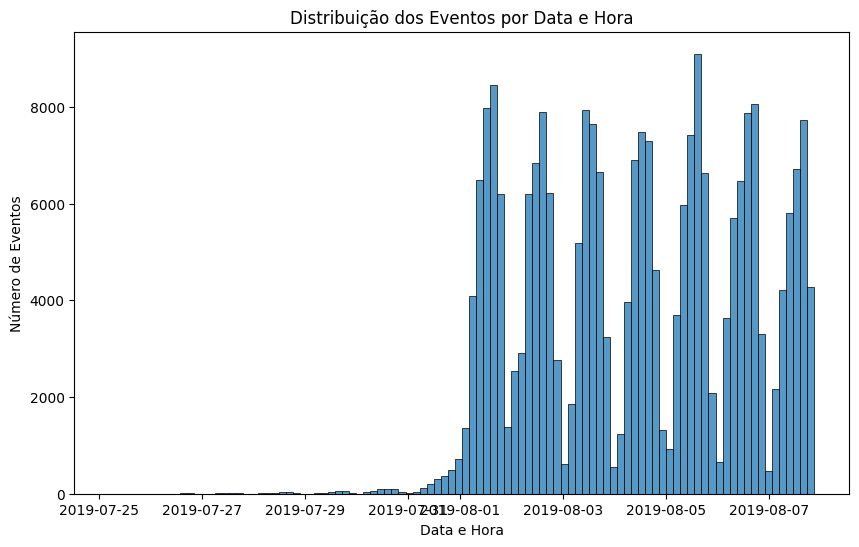

In [24]:
# Criando um histograma por data e hora
plt.figure(figsize=(10, 6))
sns.histplot(data=logs_df, x='event_datetime', bins=100)
plt.title('Distribuição dos Eventos por Data e Hora')
plt.xlabel('Data e Hora')
plt.ylabel('Número de Eventos')
plt.show()

In [25]:
# Verificando a quantidade de eventos por dia
logs_df['event_date'].value_counts().sort_index()

2019-07-25        9
2019-07-26       31
2019-07-27       55
2019-07-28      105
2019-07-29      184
2019-07-30      412
2019-07-31     2030
2019-08-01    36141
2019-08-02    35554
2019-08-03    33282
2019-08-04    32968
2019-08-05    36058
2019-08-06    35788
2019-08-07    31096
Name: event_date, dtype: int64

In [26]:
# Filtrando apenas o período em que os dados começam a ser completos
logs_complete = logs_df[logs_df['event_datetime'] >= '2019-08-01'].copy()
print(logs_complete)

                event_name              user_id  event_timestamp exp_id  \
2828              Tutorial  3737462046622621720       1564618048    246   
2829      MainScreenAppear  3737462046622621720       1564618080    246   
2830      MainScreenAppear  3737462046622621720       1564618135    246   
2831    OffersScreenAppear  3737462046622621720       1564618138    246   
2832      MainScreenAppear  1433840883824088890       1564618139    247   
...                    ...                  ...              ...    ...   
244121    MainScreenAppear  4599628364049201812       1565212345    247   
244122    MainScreenAppear  5849806612437486590       1565212439    246   
244123    MainScreenAppear  5746969938801999050       1565212483    246   
244124    MainScreenAppear  5746969938801999050       1565212498    246   
244125  OffersScreenAppear  5746969938801999050       1565212517    246   

            event_datetime  event_date  
2828   2019-08-01 00:07:28  2019-08-01  
2829   2019-08-01

A distribuição dos eventos ao longo do tempo mostrou que os primeiros dias apresentam um volume significativamente menor de registros, indicando que os dados ainda não estavam completos. A partir de 01-08-2019, o número de eventos se torna consistente, sugerindo o início de uma coleta estável. Para evitar que registros incompletos distorçam a análise, foram considerados apenas os eventos a partir dessa data. Dessa forma, o período efetivamente analisado corresponde de 01-08 -2019 até a data máxima de 07-08-2019. Após a criação do DataFrame filtrado, o número de linhas diminuiu de 243713 para 240887, ou seja, reduziu em 2826 linhas, que representa em torno de 1.16% do total, fazendo sentido já que os primeiros dias mostraram ter volume bem menor no histograma.

In [27]:
# Calculando a quantidade de eventos perdidos após a exclusão dos dados mais antigos
events_before = logs_df.shape[0]
events_after = logs_complete.shape[0]
events_lost = events_before - events_after
events_lost_perc = (events_lost / events_before) * 100
print(events_lost_perc)

1.159560630741897


In [28]:
# Calculando a quantidade de usuários perdidos após a exclusão dos dados mais antigos
users_before = logs_df['user_id'].nunique()
users_after = logs_complete['user_id'].nunique()
users_lost = users_before - users_after
users_lost_perc = (users_lost / users_before) * 100
print(users_lost_perc)

0.22513574361011784


Após a exclusão dos dados referentes ao período inicial, foram perdidos em torno de apenas 1,16% dos eventos e 0,23% dos usuários. Essa perda é pequena e indica que a remoção dos registros antigos não compromete a representatividade da amostra. Como os primeiros registros apresentavam indícios de coleta incompleta, sua exclusão contribui para uma análise mais confiável do comportamento dos usuários, reduzindo o risco de vieses causados por dados incompletos. O fato da perda de eventos ter sido maior que a perda de usuários sugere que muitos usuários realizaram eventos tanto antes quanto depois do início da coleta completa, perdendo apenas parte de seu histórico. Portanto, os poucos usuários removidos por completo registraram eventos apenas no período inicial. Dessa forma, a exclusão afetou principalmente eventos incompletos, preservando praticamente toda a população de usuários para as análises seguintes.

In [29]:
# Certificando ter usuários de todos os três grupos experimentais.
users_per_group = logs_complete.groupby('exp_id')['user_id'].nunique()
print(users_per_group)

exp_id
246    2484
247    2513
248    2537
Name: user_id, dtype: int64


Após a limpeza dos 413 duplicados, foram encontrados 243713 eventos registrados. Além disso, descobriu-se 7551 usuários únicos nos registros e uma média de eventos por usuário em torno de 32. 
A análise do período de coleta mostrou que os dados abrangem a data de 25-07-2019 até 07-08-2019. No entanto, o histograma por data e hora revelou que os primeiros dias apresentam um volume reduzido de eventos, indicando que a coleta ainda não estava completa nesse período. Por esse motivo, os registros anteriores ao início da coleta consistente foram excluídos, preservando os dados a partir de 01-08-2019, que apresentou números de eventos mais consistentes, o que permitiu garantir maior confiabilidade às análises posteriores. Essa exclusão teve impacto mínimo na base de dados, resultando na perda de apenas em torno de 1,16% dos eventos e 0,23% dos usuários, o que demonstra que a representatividade da amostra foi preservada. Ademais, verificou-se que os três grupos experimentais (246, 247 e 248) permaneceram presentes após o filtro, com usuários em todos eles, sendo de 2484, 2513 e 2537, respectivamente. Os grupos experimentais 246, 247 e 248 apresentam uma distribuição equilibrada de usuários, logo essa proximidade indica que a divisão da amostra foi adequada e permite uma comparação mais confiável entre os grupos, reduzindo o risco de que diferenças nos resultados sejam causadas pelo tamanho desigual das amostras.

# Passo 4 - Estudando o funil de eventos

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

Funil bem construído, com a proporção de usuários em cada etapa e a conversão de uma para a seguinte. Vale reparar no que os números contam: a maior perda está logo na **primeira passagem** (da tela principal para as ofertas), enquanto do carrinho para o pagamento quase todos seguem adiante. Ou seja, o gargalo está na entrada do funil, e não no fechamento da compra.
</div>

In [30]:
# Contando a frequência de ocorrência de cada evento
event_frequency = logs_complete['event_name'].value_counts()
print(event_frequency)

MainScreenAppear           117328
OffersScreenAppear          46333
CartScreenAppear            42303
PaymentScreenSuccessful     33918
Tutorial                     1005
Name: event_name, dtype: int64


A análise de frequência dos eventos mostrou que o evento mais recorrente foi a visualização da tela principal (MainScreenAppear), disparadamente com 117328 ocorrências, indicando que essa é a etapa mais comum da jornada dos usuários. A visualização de ofertas (OffersScreenAppear) ficou abaixo da visualização da tela principal, com 46333 ocorrências, já que nem todos os usuários que entram no aplicativo chegam até essa etapa. Eventos relacionados ao funil de compra, como acesso ao carrinho (CartScreenAppear) e pagamento (PaymentScreenAppear), apresentaram menor frequência em comparação aos dois eventos citados anteriormente, sendo de 42303 e 33918, respectivamente, representando etapas mais avançadas da navegação. Além disso, Tutorial apresentou a menor ocorrência de todas, com apenas 1005, podendo ser explicado pelo fato de que essa etapa provavelmente é apresentada apenas no primeiro acesso do usuário ou pode ser ignorada por parte deles. Diferentemente de eventos de navegação, que podem ocorrer diversas vezes, o evento Tutorial tende a acontecer apenas uma vez, resultando em uma menor quantidade de registros. Dessa forma, normalmente como a navegação segue o caminho: Tela principal → Ofertas → Carrinho → Pagamento e cada etapa desse funil tem uma quantidade menor de usuários, é esperado que a frequência diminua conforme o usuário avança, assim como foi inferido nesse contexto.

In [31]:
# Contando usuários únicos
total_users = logs_complete['user_id'].nunique()
print(total_users)

7534


In [32]:
# Contando o número de usuários por evento
users_per_event = logs_complete.groupby('event_name')['user_id'].nunique().sort_values(ascending=False)
print(users_per_event)

event_name
MainScreenAppear           7419
OffersScreenAppear         4593
CartScreenAppear           3734
PaymentScreenSuccessful    3539
Tutorial                    840
Name: user_id, dtype: int64


In [33]:
# Calculando a proporção de usuários que executaram a ação pelo menos uma vez
user_proportion = (users_per_event / total_users) * 100
print(user_proportion)

event_name
MainScreenAppear           98.473586
OffersScreenAppear         60.963632
CartScreenAppear           49.561986
PaymentScreenSuccessful    46.973719
Tutorial                   11.149456
Name: user_id, dtype: float64


A tabela users_per_event foi ordenada pelo número de usuários que executaram cada evento, e não pela sequência em que os eventos ocorrem no aplicativo. A proporção de usuários por evento mostra que MainScreenAppear foi a ação realizada pela maior parte dos usuários, com em torno de 98.5%, indicando que praticamente todos acessaram a tela principal do aplicativo. À medida que os eventos avançam na jornada do usuário, os dados sugerem que a proporção diminui, significando que parte dos usuários abandona o fluxo antes de concluir todas as etapas. O evento Tutorial apresentou a menor proporção de usuários, com em torno de 11.1%, indicando que poucos usuários visualizaram o tutorial, possivelmente por ser uma etapa opcional ou por já conhecerem o funcionamento do aplicativo. Vale destacar que a soma das proporções ultrapassa 100%, pois um mesmo usuário pode executar vários eventos diferentes ao longo da navegação.

A sequência mais provável da jornada do usuário é MainScreenAppear → OffersScreenAppear → CartScreenAppear → PaymentScreenSuccessful, representando o fluxo principal desde a entrada no aplicativo até a conclusão da compra. O evento Tutorial não parece fazer parte dessa sequência, pois apresenta uma proporção de usuários muito menor e provavelmente corresponde a uma funcionalidade opcional ou exibida apenas para novos usuários. Por esse motivo, esse evento não deve ser considerado na construção do funil de conversão, que deve refletir apenas as etapas da jornada principal do usuário.

In [34]:
# Usando o funil de eventos para encontrar a parcela de usuários que passam de uma etapa para a próxima 
funnel = (logs_complete.groupby('event_name')['user_id'].nunique().loc[['MainScreenAppear','OffersScreenAppear','CartScreenAppear','PaymentScreenSuccessful']])
conversion = (funnel / funnel.shift(1) * 100).round(2)
print(conversion)

event_name
MainScreenAppear             NaN
OffersScreenAppear         61.91
CartScreenAppear           81.30
PaymentScreenSuccessful    94.78
Name: user_id, dtype: float64


A análise do funil de eventos mostra que a maior perda de usuários ocorre na transição entre MainScreenAppear e OffersScreenAppear (em torno de 61.91% dos usuários que abriram a tela principal chegaram à tela de ofertas), indicando que muitos usuários acessam a tela principal, mas não avançam para a visualização das ofertas. Nas etapas seguintes, as taxas de conversão são mais elevadas: a maioria dos usuários (em torno de 81.30%) que visualiza as ofertas segue para o carrinho e, dentre aqueles que chegam ao carrinho, quase todos (em torno de 94.78%) concluem o pagamento. 
Esses resultados sugerem que a maior perda de usuários ocorre entre MainScreenAppear e OffersScreenAppear, que é o início da jornada, onde aproximadamente 38% (100% - 61.91%) dos usuários deixam de avançar para a etapa seguinte. Esse é o ponto de maior abandono do funil, enquanto as etapas posteriores apresentam taxas de conversão mais elevadas.

In [35]:
# Calculando a parcela de usuários que faz o caminho inteiro, desde o primeiro evento até o pagamento
full_conversion = ((funnel['PaymentScreenSuccessful'] / funnel['MainScreenAppear']) * 100).round(2)
print(full_conversion)

47.7


Aproximadamente 47.7% dos usuários que acessaram a tela principal concluíram o pagamento. Isso significa que quase metade dos usuários percorreu todas as etapas do funil de conversão com sucesso, enquanto a outra metade abandonou o processo em alguma etapa da jornada. Já foi inferido que a maior parte desse abandono ocorre logo no início do funil, entre a tela principal e a tela de ofertas.

# Passo 5 - Estudando os resultados do experimento

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

Sequência metodológica correta: primeiro o **teste A/A** entre os dois controles, para confirmar que o mecanismo de divisão dos grupos funciona, e só depois a comparação com o grupo experimental. Sem essa validação, qualquer diferença encontrada depois seria suspeita.
</div>

Acima, em users_per_group, já foi calculado que para o grupo 246 há 2484 usuários, para o grupo 247 há 2513 e para o grupo 248 há 2537 usuários.

Para comparar os grupos 246 e 247 em um teste A/A, será feito um teste Z bilateral para comparação de proporções. A ideia é verificar se a proporção de usuários que realizou um determinado evento é diferente entre os dois grupos. 
Justificativa para a escolha do teste Z bilateral: Como se trata de um teste A/A, o objetivo é identificar qualquer diferença estatisticamente significativa entre os grupos de controle, independentemente de qual grupo apresentasse maior ou menor conversão. Por isso, a hipótese alternativa considera que as proporções poderiam ser diferentes em qualquer direção.

H₀ (hipótese nula): Não existe diferença estatisticamente significativa entre as proporções de usuários dos grupos 246 e 247 que realizaram o evento analisado.

H₁ (hipótese alternativa): Existe uma diferença estatisticamente significativa entre as proporções de usuários dos grupos 246 e 247 que realizaram o evento analisado.

alpha = 0.05 (valor do nível de significância mais utilizado em análises estatísticas, que significa que você aceita uma probabilidade de 5% de cometer um erro).

In [36]:
# Realizando o teste Z bilateral para verificar se há diferença estatisticamente significativa entre as amostragens 246 e 247 dos 4 eventos mais populares

events = ['MainScreenAppear','OffersScreenAppear','CartScreenAppear','PaymentScreenSuccessful']

alpha = 0.05

n1 = logs_complete[logs_complete['exp_id'] == 246]['user_id'].nunique()
n2 = logs_complete[logs_complete['exp_id'] == 247]['user_id'].nunique()

for event in events:
    x1 = logs_complete[(logs_complete['exp_id'] == 246) & (logs_complete['event_name'] == event)]['user_id'].nunique()

    x2 = logs_complete[(logs_complete['exp_id'] == 247) & (logs_complete['event_name'] == event)]['user_id'].nunique()

    p1 = x1 / n1
    p2 = x2 / n2

    p_combined = (x1 + x2) / (n1 + n2)

    standard_error = math.sqrt(p_combined * (1 - p_combined) * (1/n1 + 1/n2))

    z = (p1 - p2) / standard_error

    p_value = 2 * (1 - st.norm.cdf(abs(z)))

    print(event)
    print('p-value:', round(p_value, 4))

    if p_value < alpha:
        print("Rejeitamos a hipótese nula")
    else:
        print("Não podemos rejeitar a hipótese nula")


MainScreenAppear
p-value: 0.7571
Não podemos rejeitar a hipótese nula
OffersScreenAppear
p-value: 0.2481
Não podemos rejeitar a hipótese nula
CartScreenAppear
p-value: 0.2288
Não podemos rejeitar a hipótese nula
PaymentScreenSuccessful
p-value: 0.1146
Não podemos rejeitar a hipótese nula


O teste Z bilateral foi aplicado para comparar as proporções de usuários que realizaram os principais eventos (MainScreenAppear, OffersScreenAppear, CartScreenAppear e PaymentScreenSuccessful) nos grupos de controle 246 e 247. Para esses eventos analisados, os valores de p-value foram superiores ao nível de significância adotado de 0.05, sendo de 0.7571, 0.2481, 0.2288 e 0.1146, respectivamente. Portanto, não foi possível rejeitar a hipótese nula de que não há diferença estatisticamente significativa entre as proporções de usuários dos grupos 246 e 247 que realizaram o evento analisado, ou seja, não há evidências estatísticas de diferenças significativas entre os dois grupos de controle. Esses resultados mostram que os grupos de controle apresentam comportamentos semelhantes em todas as etapas do funil. Dessa forma, o teste A/A confirmou que os grupos 246 e 247 possuem comportamento semelhante, indicando que a divisão dos usuários foi adequada e permitindo uma comparação futura mais confiável com o grupo experimental. Como vários eventos foram testados simultaneamente, existe o risco de falsos positivos devido às comparações múltiplas. O problema de comparações múltiplas é mais preocupante quando há vários testes e alguns p-valores muito próximos de 0.05, pois um deles poderia ser significativo apenas por acaso. Nesse caso analisado, o menor p-value foi 0.1146, que ainda está bem distante de 0.05, logo, mesmo considerando o risco pequeno de falso positivo, a conclusão permanece a mesma: os grupos 246 e 247 não apresentam diferenças estatisticamente significativas.

Já foi identificado, por meio da variável users_per_event, que o evento mais popular é MainScreenAppear.

Para esse teste Z bilateral, será adotado o mesmo raciocínio, a diferença é que considerará todos os eventos registrados no aplicativo.

Como se trata de um teste A/A, o objetivo é identificar qualquer diferença estatisticamente significativa entre os grupos de controle, independentemente de qual grupo apresentasse maior ou menor conversão. Por isso, a hipótese alternativa considera que as proporções poderiam ser diferentes em qualquer direção.

H₀ (hipótese nula): Não existe diferença estatisticamente significativa entre as proporções de usuários dos grupos 246 e 247 que realizaram o evento analisado.

H₁ (hipótese alternativa): Existe uma diferença estatisticamente significativa entre as proporções de usuários dos grupos 246 e 247 que realizaram o evento analisado.

alpha = 0.05 (valor do nível de significância mais utilizado em análises estatísticas, que significa que você aceita uma probabilidade de 5% de cometer um erro).

In [37]:
# Realizando o teste Z bilateral para encontrar o número de usuários que realizaram cada ação em cada grupo de controle

events = logs_complete['event_name'].unique()

alpha = 0.05

n1 = logs_complete[logs_complete['exp_id'] == 246]['user_id'].nunique()
n2 = logs_complete[logs_complete['exp_id'] == 247]['user_id'].nunique()

for event in events:
    
    x1 = logs_complete[(logs_complete['exp_id'] == 246) & (logs_complete['event_name'] == event)]['user_id'].nunique()

    x2 = logs_complete[(logs_complete['exp_id'] == 247) & (logs_complete['event_name'] == event)]['user_id'].nunique()

    p1 = x1 / n1
    p2 = x2 / n2

    p_combined = (x1 + x2) / (n1 + n2)

    standard_error = math.sqrt(p_combined * (1 - p_combined) * (1/n1 + 1/n2))

    z = (p1 - p2) / standard_error

    p_value = 2 * (1 - st.norm.cdf(abs(z)))

    print(f'Evento: {event}')
    print(f'Grupo 246: {x1} usuários ({p1:.2%})')
    print(f'Grupo 247: {x2} usuários ({p2:.2%})')
    print(f'p-value: {p_value:.4f}')

    if p_value < alpha:
        print("Rejeitamos a hipótese nula")
    else:
        print("Não podemos rejeitar a hipótese nula")


Evento: Tutorial
Grupo 246: 278 usuários (11.19%)
Grupo 247: 283 usuários (11.26%)
p-value: 0.9377
Não podemos rejeitar a hipótese nula
Evento: MainScreenAppear
Grupo 246: 2450 usuários (98.63%)
Grupo 247: 2476 usuários (98.53%)
p-value: 0.7571
Não podemos rejeitar a hipótese nula
Evento: OffersScreenAppear
Grupo 246: 1542 usuários (62.08%)
Grupo 247: 1520 usuários (60.49%)
p-value: 0.2481
Não podemos rejeitar a hipótese nula
Evento: CartScreenAppear
Grupo 246: 1266 usuários (50.97%)
Grupo 247: 1238 usuários (49.26%)
p-value: 0.2288
Não podemos rejeitar a hipótese nula
Evento: PaymentScreenSuccessful
Grupo 246: 1200 usuários (48.31%)
Grupo 247: 1158 usuários (46.08%)
p-value: 0.1146
Não podemos rejeitar a hipótese nula


Inicialmente, foi identificado o evento mais popular, MainScreenAppear, realizado por 98.63% dos usuários do grupo 246 e 98.53% dos usuários do grupo 247, indicando que praticamente todos os usuários acessaram a tela principal do aplicativo. Em seguida, o mesmo procedimento foi aplicado aos demais eventos, calculando o número de usuários, a proporção em cada grupo e realizando um teste Z bilateral para comparar as proporções. Os resultados mostraram que, para todos os eventos analisados (Tutorial, MainScreenAppear, OffersScreenAppear, CartScreenAppear e PaymentScreenSuccessful), os valores de p-value foram superiores ao nível de significância de 0.05. Assim, em nenhum caso foi possível rejeitar a hipótese nula de que as proporções de usuários dos grupos 246 e 247 são iguais. Embora existam pequenas diferenças nas proporções observadas entre os grupos, por exemplo, 62.08% contra 60.49% em OffersScreenAppear e 48.31% contra 46.08% em PaymentScreenSuccessful, essas diferenças não são estatisticamente significativas e podem ser atribuídas à variabilidade aleatória da amostragem. Além disso, os valores de p-value encontrados (0.9377 para Tutorial, 0.7571 para MainScreenAppear, 0.2481 para OffersScreenAppear, 0.2288 para CartScreenAppear e 0.1146 para PaymentScreenSuccessful) estão todos acima do limite de 0.05, indicando que não há evidências de diferenças sistemáticas entre os grupos de controle. Mesmo considerando que foram realizados testes para múltiplos eventos, o risco de falsos positivos é baixo neste caso, pois nenhum dos valores de p-value ficou próximo do nível de significância. Portanto, os resultados confirmam que os grupos de controle 246 e 247 foram divididos de forma equilibrada e apresentam comportamento semelhante em todas as etapas analisadas. Isso valida o teste A/A, aumenta a confiança de que o processo de aleatorização foi realizado corretamente e fornece uma base confiável para as próximas etapas da análise.
Ademais, como falado anteriormente, faz mais sentido tratar o evento Tutorial separadamente, já que ele não faz parte da mesma jornada lógica dos demais eventos do funil, devido ao fato de que nem todo usuário precisa realizá-lo para utilizar o aplicativo. Isso explica o motivo de cerca de apenas 11% dos usuários realizaram esse evento, enquanto quase 99% acessaram a tela principal.

In [38]:
# Realizando o teste Z bilateral para comparar o Grupo 246 (controle) com o Grupo 248 (experimental)
events = logs_complete['event_name'].unique()

alpha = 0.05

n1 = logs_complete[logs_complete['exp_id'] == 246]['user_id'].nunique()
n2 = logs_complete[logs_complete['exp_id'] == 248]['user_id'].nunique()

for event in events:

    x1 = logs_complete[(logs_complete['exp_id'] == 246) & (logs_complete['event_name'] == event)]['user_id'].nunique()

    x2 = logs_complete[(logs_complete['exp_id'] == 248) & (logs_complete['event_name'] == event)]['user_id'].nunique()

    p1 = x1 / n1
    p2 = x2 / n2

    p_combined = (x1 + x2) / (n1 + n2)

    standard_error = math.sqrt(p_combined * (1 - p_combined) * (1/n1 + 1/n2))

    z = (p1 - p2) / standard_error

    p_value = 2 * (1 - st.norm.cdf(abs(z)))

    print(f'Evento: {event}')
    print(f'Grupo 246: {x1} usuários ({p1:.2%})')
    print(f'Grupo 248: {x2} usuários ({p2:.2%})')
    print(f'p-value: {p_value:.4f}')

    if p_value < alpha:
        print("Rejeitamos a hipótese nula")
    else:
        print("Não podemos rejeitar a hipótese nula")

Evento: Tutorial
Grupo 246: 278 usuários (11.19%)
Grupo 248: 279 usuários (11.00%)
p-value: 0.8264
Não podemos rejeitar a hipótese nula
Evento: MainScreenAppear
Grupo 246: 2450 usuários (98.63%)
Grupo 248: 2493 usuários (98.27%)
p-value: 0.2950
Não podemos rejeitar a hipótese nula
Evento: OffersScreenAppear
Grupo 246: 1542 usuários (62.08%)
Grupo 248: 1531 usuários (60.35%)
p-value: 0.2084
Não podemos rejeitar a hipótese nula
Evento: CartScreenAppear
Grupo 246: 1266 usuários (50.97%)
Grupo 248: 1230 usuários (48.48%)
p-value: 0.0784
Não podemos rejeitar a hipótese nula
Evento: PaymentScreenSuccessful
Grupo 246: 1200 usuários (48.31%)
Grupo 248: 1181 usuários (46.55%)
p-value: 0.2123
Não podemos rejeitar a hipótese nula


In [39]:
# Realizando o teste Z bilateral para comparar o Grupo 247 (controle) com o Grupo 248 (experimental)
events = logs_complete['event_name'].unique()

alpha = 0.05

n1 = logs_complete[logs_complete['exp_id'] == 247]['user_id'].nunique()
n2 = logs_complete[logs_complete['exp_id'] == 248]['user_id'].nunique()

for event in events:

    x1 = logs_complete[(logs_complete['exp_id'] == 247) & (logs_complete['event_name'] == event)]['user_id'].nunique()

    x2 = logs_complete[(logs_complete['exp_id'] == 248) & (logs_complete['event_name'] == event)]['user_id'].nunique()

    p1 = x1 / n1
    p2 = x2 / n2

    p_combined = (x1 + x2) / (n1 + n2)

    standard_error = math.sqrt(p_combined * (1 - p_combined) * (1/n1 + 1/n2))

    z = (p1 - p2) / standard_error

    p_value = 2 * (1 - st.norm.cdf(abs(z)))

    print(f'Evento: {event}')
    print(f'Grupo 247: {x1} usuários ({p1:.2%})')
    print(f'Grupo 248: {x2} usuários ({p2:.2%})')
    print(f'p-value: {p_value:.4f}')

    if p_value < alpha:
        print("Rejeitamos a hipótese nula")
    else:
        print("Não podemos rejeitar a hipótese nula")

Evento: Tutorial
Grupo 247: 283 usuários (11.26%)
Grupo 248: 279 usuários (11.00%)
p-value: 0.7653
Não podemos rejeitar a hipótese nula
Evento: MainScreenAppear
Grupo 247: 2476 usuários (98.53%)
Grupo 248: 2493 usuários (98.27%)
p-value: 0.4587
Não podemos rejeitar a hipótese nula
Evento: OffersScreenAppear
Grupo 247: 1520 usuários (60.49%)
Grupo 248: 1531 usuários (60.35%)
p-value: 0.9198
Não podemos rejeitar a hipótese nula
Evento: CartScreenAppear
Grupo 247: 1238 usuários (49.26%)
Grupo 248: 1230 usuários (48.48%)
p-value: 0.5786
Não podemos rejeitar a hipótese nula
Evento: PaymentScreenSuccessful
Grupo 247: 1158 usuários (46.08%)
Grupo 248: 1181 usuários (46.55%)
p-value: 0.7373
Não podemos rejeitar a hipótese nula


In [40]:
# Realizando o teste Z bilateral para comparar os Grupos de Controle 246 + 247 com o Grupo Experimental 248
events = logs_complete['event_name'].unique()

alpha = 0.05

control = logs_complete[logs_complete['exp_id'].isin([246,247])]

n1 = control['user_id'].nunique()
n2 = logs_complete[logs_complete['exp_id']==248]['user_id'].nunique()

for event in events:

    x1 = control[control['event_name']==event]['user_id'].nunique()

    x2 = logs_complete[(logs_complete['exp_id']==248) & (logs_complete['event_name']==event)]['user_id'].nunique()

    p1 = x1/n1
    p2 = x2/n2

    p_combined = (x1+x2)/(n1+n2)

    standard_error = math.sqrt(p_combined*(1-p_combined)*(1/n1+1/n2))

    z = (p1-p2)/standard_error

    p_value = 2*(1-st.norm.cdf(abs(z)))

    print(event)
    print(f'Controle: {x1} usuários ({p1:.2%})')
    print(f'Grupo 248: {x2} usuários ({p2:.2%})')
    print(f'p-value: {p_value:.4f}')

    if p_value < alpha:
        print("Rejeitamos a hipótese nula")
    else:
        print("Não podemos rejeitar a hipótese nula")

Tutorial
Controle: 561 usuários (11.23%)
Grupo 248: 279 usuários (11.00%)
p-value: 0.7649
Não podemos rejeitar a hipótese nula
MainScreenAppear
Controle: 4926 usuários (98.58%)
Grupo 248: 2493 usuários (98.27%)
p-value: 0.2942
Não podemos rejeitar a hipótese nula
OffersScreenAppear
Controle: 3062 usuários (61.28%)
Grupo 248: 1531 usuários (60.35%)
p-value: 0.4343
Não podemos rejeitar a hipótese nula
CartScreenAppear
Controle: 2504 usuários (50.11%)
Grupo 248: 1230 usuários (48.48%)
p-value: 0.1818
Não podemos rejeitar a hipótese nula
PaymentScreenSuccessful
Controle: 2358 usuários (47.19%)
Grupo 248: 1181 usuários (46.55%)
p-value: 0.6004
Não podemos rejeitar a hipótese nula


Após validar o teste A/A, foram realizadas comparações entre o grupo experimental (248) e cada um dos grupos de controle (246 e 247), além de uma comparação com os grupos de controle combinados (246 + 247). Para cada comparação, foi aplicado um teste Z bilateral com o objetivo de verificar se a alteração da fonte provocou mudanças estatisticamente significativas na proporção de usuários que realizaram cada evento do aplicativo: MainScreenAppear, OffersScreenAppear, CartScreenAppear, PaymentScreenSuccessful e Tutorial.

Na comparação entre os grupos 246 e 248, todos os p-values foram superiores ao nível de significância de 0.05 (0.2950 para MainScreenAppear, 0.2084 para OffersScreenAppear, 0.0784 para CartScreenAppear, 0.2123 para PaymentScreenSuccessful e 0.8264 para Tutorial), indicando que não há evidências de diferenças estatisticamente significativas entre os grupos. Assim, não foi possível rejeitar a hipótese nula em nenhum dos casos, indicando que as pequenas diferenças observadas nas proporções de usuários são compatíveis com a variabilidade aleatória da amostragem e não representam um efeito estatisticamente significativo da alteração da fonte.

Na comparação entre os grupos 247 e 248, os resultados também mostraram que todas as diferenças observadas podem ser atribuídas à variabilidade aleatória da amostragem. Os p-values permaneceram acima de 0.05 para todos os eventos (0.4587 para MainScreenAppear, 0.9198 para OffersScreenAppear, 0.5786 para CartScreenAppear, 0.7373 para PaymentScreenSuccessful e 0.7653 para Tutorial), indicando que o comportamento dos usuários foi semelhante entre o grupo de controle e o grupo experimental.

Por fim, a comparação entre o grupo experimental (248) e os grupos de controle combinados (246 + 247) também não identificou diferenças estatisticamente significativas em nenhum dos eventos analisados. A utilização do grupo de controle combinado aumenta o tamanho da amostra de referência e, consequentemente, o poder estatístico da análise. Mesmo assim, todos os p-values permaneceram acima do nível de significância (0.2942 para MainScreenAppear, 0.4343 para OffersScreenAppear, 0.1818 para CartScreenAppear, 0.6004 para PaymentScreenSuccessful e 0.7649 para Tutorial), reforçando que a alteração da fonte não produziu mudanças detectáveis no comportamento dos usuários.

O evento Tutorial também foi incluído nas comparações entre o grupo experimental e os grupos de controle. No entanto, assim como discutido anteriormente, esse evento não faz parte da sequência principal do funil de conversão, pois sua execução não é obrigatória para que o usuário continue utilizando o aplicativo. Ainda assim, o teste Z indicou que não há diferenças estatisticamente significativas entre os grupos para esse evento, sugerindo que a alteração da fonte também não influenciou a probabilidade de os usuários acessarem o tutorial.

Além disso, considerando que foram realizados diversos testes estatísticos, existe a possibilidade de ocorrência de falsos positivos devido às comparações múltiplas. Entretanto, esse risco é baixo neste experimento, pois nenhum dos p-values encontrados foi inferior a 0,05.

Em conjunto, os resultados indicam que a alteração da fonte utilizada no grupo experimental não impactou significativamente o comportamento dos usuários em nenhuma etapa analisada (MainScreenAppear, OffersScreenAppear, CartScreenAppear, PaymentScreenSuccessful e Tutorial). Dessa forma, não há evidências estatísticas de que a mudança na interface tenha melhorado ou prejudicado a navegação ou a conversão dos usuários. Portanto, com base nos dados analisados, a nova fonte não apresentou benefícios mensuráveis em relação à versão original do aplicativo.

Ademais, a comparação dos p-values obtidos entre o grupo experimental e os grupos de controle com aqueles observados no teste A/A mostra que, embora seus valores variem entre os diferentes eventos e comparações, todos permaneceram acima do nível de significância de 0.05. Assim, as comparações envolvendo o grupo experimental levaram à mesma conclusão do teste A/A: não há evidências estatisticamente significativas de diferenças entre os grupos. Isso reforça que as variações observadas são compatíveis com a variabilidade aleatória da amostragem e não indicam um efeito mensurável da alteração da fonte. Em outras palavras, as diferenças observadas são comparáveis às variações naturais esperadas entre grupos distribuídos aleatoriamente.

In [41]:
# Calculando o número total de testes de hipóteses realizados
comparisons = ['246 x 247', '246 x 248', '247 x 248', 'Controle x 248']

events = logs_complete['event_name'].nunique()

total_tests = len(comparisons) * events

print(len(comparisons))
print(events)
print(total_tests)

4
5
20


In [42]:
# Calculando o novo nivel de significância
alpha = 0.05

alpha_bonferroni = alpha / total_tests

print(alpha_bonferroni)

0.0025


<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

Excelente: aplicar a **correção de Bonferroni** mostra maturidade estatística. Fazendo muitas comparações com alfa de 0,05, a chance de aparecer um resultado 'significativo' por puro acaso fica alta. Dividir o alfa pelo número de testes controla esse risco, e você contou os testes corretamente.
</div>

In [43]:
# Reexecutando o teste estatístico com o novo nível de significância de 0.0025
events = ['MainScreenAppear','OffersScreenAppear','CartScreenAppear','PaymentScreenSuccessful']

alpha = 0.0025

n1 = logs_complete[logs_complete['exp_id'] == 246]['user_id'].nunique()
n2 = logs_complete[logs_complete['exp_id'] == 247]['user_id'].nunique()

for event in events:
    x1 = logs_complete[(logs_complete['exp_id'] == 246) & (logs_complete['event_name'] == event)]['user_id'].nunique()

    x2 = logs_complete[(logs_complete['exp_id'] == 247) & (logs_complete['event_name'] == event)]['user_id'].nunique()

    p1 = x1 / n1
    p2 = x2 / n2

    p_combined = (x1 + x2) / (n1 + n2)

    standard_error = math.sqrt(p_combined * (1 - p_combined) * (1/n1 + 1/n2))

    z = (p1 - p2) / standard_error

    p_value = 2 * (1 - st.norm.cdf(abs(z)))

    print(event)
    print('p-value:', round(p_value, 4))

    if p_value < alpha:
        print("Rejeitamos a hipótese nula")
    else:
        print("Não podemos rejeitar a hipótese nula")

MainScreenAppear
p-value: 0.7571
Não podemos rejeitar a hipótese nula
OffersScreenAppear
p-value: 0.2481
Não podemos rejeitar a hipótese nula
CartScreenAppear
p-value: 0.2288
Não podemos rejeitar a hipótese nula
PaymentScreenSuccessful
p-value: 0.1146
Não podemos rejeitar a hipótese nula


In [44]:
# Reexecutando o teste estatístico com o novo nível de significância de 0.0025
events = logs_complete['event_name'].unique()

alpha = 0.0025

n1 = logs_complete[logs_complete['exp_id'] == 246]['user_id'].nunique()
n2 = logs_complete[logs_complete['exp_id'] == 247]['user_id'].nunique()

for event in events:
    
    x1 = logs_complete[(logs_complete['exp_id'] == 246) & (logs_complete['event_name'] == event)]['user_id'].nunique()

    x2 = logs_complete[(logs_complete['exp_id'] == 247) & (logs_complete['event_name'] == event)]['user_id'].nunique()

    p1 = x1 / n1
    p2 = x2 / n2

    p_combined = (x1 + x2) / (n1 + n2)

    standard_error = math.sqrt(p_combined * (1 - p_combined) * (1/n1 + 1/n2))

    z = (p1 - p2) / standard_error

    p_value = 2 * (1 - st.norm.cdf(abs(z)))

    print(f'Evento: {event}')
    print(f'Grupo 246: {x1} usuários ({p1:.2%})')
    print(f'Grupo 247: {x2} usuários ({p2:.2%})')
    print(f'p-value: {p_value:.4f}')

    if p_value < alpha:
        print("Rejeitamos a hipótese nula")
    else:
        print("Não podemos rejeitar a hipótese nula")

Evento: Tutorial
Grupo 246: 278 usuários (11.19%)
Grupo 247: 283 usuários (11.26%)
p-value: 0.9377
Não podemos rejeitar a hipótese nula
Evento: MainScreenAppear
Grupo 246: 2450 usuários (98.63%)
Grupo 247: 2476 usuários (98.53%)
p-value: 0.7571
Não podemos rejeitar a hipótese nula
Evento: OffersScreenAppear
Grupo 246: 1542 usuários (62.08%)
Grupo 247: 1520 usuários (60.49%)
p-value: 0.2481
Não podemos rejeitar a hipótese nula
Evento: CartScreenAppear
Grupo 246: 1266 usuários (50.97%)
Grupo 247: 1238 usuários (49.26%)
p-value: 0.2288
Não podemos rejeitar a hipótese nula
Evento: PaymentScreenSuccessful
Grupo 246: 1200 usuários (48.31%)
Grupo 247: 1158 usuários (46.08%)
p-value: 0.1146
Não podemos rejeitar a hipótese nula


In [45]:
# Reexecutando o teste estatístico com o novo nível de significância de 0.0025
events = logs_complete['event_name'].unique()

alpha = 0.0025

n1 = logs_complete[logs_complete['exp_id'] == 246]['user_id'].nunique()
n2 = logs_complete[logs_complete['exp_id'] == 248]['user_id'].nunique()

for event in events:

    x1 = logs_complete[(logs_complete['exp_id'] == 246) & (logs_complete['event_name'] == event)]['user_id'].nunique()

    x2 = logs_complete[(logs_complete['exp_id'] == 248) & (logs_complete['event_name'] == event)]['user_id'].nunique()

    p1 = x1 / n1
    p2 = x2 / n2

    p_combined = (x1 + x2) / (n1 + n2)

    standard_error = math.sqrt(p_combined * (1 - p_combined) * (1/n1 + 1/n2))

    z = (p1 - p2) / standard_error

    p_value = 2 * (1 - st.norm.cdf(abs(z)))

    print(f'Evento: {event}')
    print(f'Grupo 246: {x1} usuários ({p1:.2%})')
    print(f'Grupo 248: {x2} usuários ({p2:.2%})')
    print(f'p-value: {p_value:.4f}')

    if p_value < alpha:
        print("Rejeitamos a hipótese nula")
    else:
        print("Não podemos rejeitar a hipótese nula")

Evento: Tutorial
Grupo 246: 278 usuários (11.19%)
Grupo 248: 279 usuários (11.00%)
p-value: 0.8264
Não podemos rejeitar a hipótese nula
Evento: MainScreenAppear
Grupo 246: 2450 usuários (98.63%)
Grupo 248: 2493 usuários (98.27%)
p-value: 0.2950
Não podemos rejeitar a hipótese nula
Evento: OffersScreenAppear
Grupo 246: 1542 usuários (62.08%)
Grupo 248: 1531 usuários (60.35%)
p-value: 0.2084
Não podemos rejeitar a hipótese nula
Evento: CartScreenAppear
Grupo 246: 1266 usuários (50.97%)
Grupo 248: 1230 usuários (48.48%)
p-value: 0.0784
Não podemos rejeitar a hipótese nula
Evento: PaymentScreenSuccessful
Grupo 246: 1200 usuários (48.31%)
Grupo 248: 1181 usuários (46.55%)
p-value: 0.2123
Não podemos rejeitar a hipótese nula


In [46]:
# Reexecutando o teste estatístico com o novo nível de significância de 0.0025
events = logs_complete['event_name'].unique()

alpha = 0.0025

n1 = logs_complete[logs_complete['exp_id'] == 247]['user_id'].nunique()
n2 = logs_complete[logs_complete['exp_id'] == 248]['user_id'].nunique()

for event in events:

    x1 = logs_complete[(logs_complete['exp_id'] == 247) & (logs_complete['event_name'] == event)]['user_id'].nunique()

    x2 = logs_complete[(logs_complete['exp_id'] == 248) & (logs_complete['event_name'] == event)]['user_id'].nunique()

    p1 = x1 / n1
    p2 = x2 / n2

    p_combined = (x1 + x2) / (n1 + n2)

    standard_error = math.sqrt(p_combined * (1 - p_combined) * (1/n1 + 1/n2))

    z = (p1 - p2) / standard_error

    p_value = 2 * (1 - st.norm.cdf(abs(z)))

    print(f'Evento: {event}')
    print(f'Grupo 247: {x1} usuários ({p1:.2%})')
    print(f'Grupo 248: {x2} usuários ({p2:.2%})')
    print(f'p-value: {p_value:.4f}')

    if p_value < alpha:
        print("Rejeitamos a hipótese nula")
    else:
        print("Não podemos rejeitar a hipótese nula")

Evento: Tutorial
Grupo 247: 283 usuários (11.26%)
Grupo 248: 279 usuários (11.00%)
p-value: 0.7653
Não podemos rejeitar a hipótese nula
Evento: MainScreenAppear
Grupo 247: 2476 usuários (98.53%)
Grupo 248: 2493 usuários (98.27%)
p-value: 0.4587
Não podemos rejeitar a hipótese nula
Evento: OffersScreenAppear
Grupo 247: 1520 usuários (60.49%)
Grupo 248: 1531 usuários (60.35%)
p-value: 0.9198
Não podemos rejeitar a hipótese nula
Evento: CartScreenAppear
Grupo 247: 1238 usuários (49.26%)
Grupo 248: 1230 usuários (48.48%)
p-value: 0.5786
Não podemos rejeitar a hipótese nula
Evento: PaymentScreenSuccessful
Grupo 247: 1158 usuários (46.08%)
Grupo 248: 1181 usuários (46.55%)
p-value: 0.7373
Não podemos rejeitar a hipótese nula


In [47]:
# Reexecutando o teste estatístico com o novo nível de significância de 0.0025
events = logs_complete['event_name'].unique()

alpha = 0.0025

control = logs_complete[logs_complete['exp_id'].isin([246,247])]

n1 = control['user_id'].nunique()
n2 = logs_complete[logs_complete['exp_id']==248]['user_id'].nunique()

for event in events:

    x1 = control[control['event_name']==event]['user_id'].nunique()

    x2 = logs_complete[(logs_complete['exp_id']==248) & (logs_complete['event_name']==event)]['user_id'].nunique()

    p1 = x1/n1
    p2 = x2/n2

    p_combined = (x1+x2)/(n1+n2)

    standard_error = math.sqrt(p_combined*(1-p_combined)*(1/n1+1/n2))

    z = (p1-p2)/standard_error

    p_value = 2*(1-st.norm.cdf(abs(z)))

    print(event)
    print(f'Controle: {x1} usuários ({p1:.2%})')
    print(f'Grupo 248: {x2} usuários ({p2:.2%})')
    print(f'p-value: {p_value:.4f}')

    if p_value < alpha:
        print("Rejeitamos a hipótese nula")
    else:
        print("Não podemos rejeitar a hipótese nula")

Tutorial
Controle: 561 usuários (11.23%)
Grupo 248: 279 usuários (11.00%)
p-value: 0.7649
Não podemos rejeitar a hipótese nula
MainScreenAppear
Controle: 4926 usuários (98.58%)
Grupo 248: 2493 usuários (98.27%)
p-value: 0.2942
Não podemos rejeitar a hipótese nula
OffersScreenAppear
Controle: 3062 usuários (61.28%)
Grupo 248: 1531 usuários (60.35%)
p-value: 0.4343
Não podemos rejeitar a hipótese nula
CartScreenAppear
Controle: 2504 usuários (50.11%)
Grupo 248: 1230 usuários (48.48%)
p-value: 0.1818
Não podemos rejeitar a hipótese nula
PaymentScreenSuccessful
Controle: 2358 usuários (47.19%)
Grupo 248: 1181 usuários (46.55%)
p-value: 0.6004
Não podemos rejeitar a hipótese nula


Inicialmente, o nível de significância (alpha) definido foi de 0.05. Para este experimento, um alpha de 0.1 seria muito permissivo, principalmente porque foram realizados vários testes de hipóteses (20). Um nível de significância de 0.1 (10%) significa que aceitaríamos uma chance maior de encontrar um falso positivo, ou seja, poderíamos concluir que a alteração da fonte teve algum efeito quando, na verdade, a diferença observada ocorreu apenas por acaso. Quando muitos testes são feitos, a probabilidade acumulada de encontrar pelo menos um resultado "significativo" por acaso aumenta. Portanto, usar um alpha maior, como 0.1, aumentaria ainda mais esse risco. Após considerar o problema de comparações múltiplas, foi aplicado o ajuste de Bonferroni. Como foram realizados 20 testes de hipóteses, o novo nível de significância foi calculado como α = 0.05 / 20 = 0.0025. Os testes estatísticos foram avaliados novamente utilizando esse novo limite de significância. Como nenhum dos p-values obtidos foi inferior a 0.0025, todas as conclusões permaneceram inalteradas. Portanto, mesmo utilizando um critério estatístico mais rigoroso, já que quanto menor o nível de significância (alpha) mais rigoroso é o teste, não foram encontradas evidências de diferenças significativas entre os grupos, indicando que a alteração da fonte não teve impacto mensurável no comportamento dos usuários.

# Conclusão

A análise do comportamento dos usuários no aplicativo foi dividida em duas etapas principais: o estudo do funil de vendas e a avaliação do experimento A/A/B relacionado à alteração das fontes do aplicativo.

Na análise do funil, foi possível identificar a jornada dos usuários desde o primeiro contato com o aplicativo até a conclusão da compra. O evento mais frequente foi MainScreenAppear, com 117328 ocorrências, indicando que a grande maioria dos usuários acessou a tela principal do aplicativo. A partir dessa etapa, observou-se uma redução gradual no número de usuários conforme eles avançavam no processo de compra, passando pelas etapas de visualização das ofertas (OffersScreenAppear), acesso ao carrinho (CartScreenAppear) e finalização do pagamento (PaymentScreenSuccessful), sendo as ocorrências de 46333, 42303 e 33918, respectivamente.

A maior perda de usuários ocorreu na transição entre a tela principal e a visualização das ofertas, já que apenas em torno de 61.91% dos usuários que abriram a tela principal chegaram à tela de ofertas, indicando que essa etapa representa o principal ponto de abandono do funil. Já a etapa final de pagamento apresentou uma taxa de conversão alta (94.78%) entre os usuários que chegaram ao carrinho, sugerindo que os usuários que avançam até essa fase possuem maior intenção de compra. Considerando todo o caminho do funil, aproximadamente 47.7% dos usuários que iniciaram a jornada chegaram até a etapa de pagamento, mostrando que existe uma parcela significativa de usuários que não conclui o processo de compra e, por isso, a empresa pode investigar formas de reduzir esses abandonos.

O evento Tutorial foi analisado com uma ressalva, pois ele possui uma característica diferente dos demais eventos do funil: seu acesso não é obrigatório para que o usuário continue utilizando o aplicativo e realizando uma compra. Portanto, embora tenha sido incluído nos testes estatísticos para verificar se a nova fonte influenciou também esse comportamento inicial, ele não representa uma etapa obrigatória da jornada de conversão e deve ser interpretado separadamente dos eventos principais do funil (MainScreenAppear, OffersScreenAppear, CartScreenAppear e PaymentScreenSuccessful).

Posteriormente, foi realizado o teste A/A/B para avaliar se a alteração das fontes do aplicativo influenciou o comportamento dos usuários. Inicialmente, foi realizada a comparação entre os dois grupos de controle (246 e 247). Como ambos receberam a versão original do aplicativo, esperava-se que apresentassem comportamentos semelhantes. Os testes estatísticos não identificaram diferenças significativas entre esses grupos para nenhum dos eventos analisados, indicando que a divisão dos usuários entre os grupos de controle foi realizada de forma adequada e aleatória. Essa validação é importante, pois aumenta a confiança de que eventuais diferenças observadas posteriormente entre o grupo experimental e os grupos de controle seriam causadas pela alteração da fonte, e não por diferenças pré-existentes entre os grupos de controle.

Em seguida, o grupo experimental (248), que recebeu a nova fonte, foi comparado individualmente com cada grupo de controle (246 e 247) e também com os grupos de controle combinados. Para todos os eventos analisados, os valores de p-value permaneceram acima do nível de significância adotado de 0.05, indicando que não houve evidências estatísticas suficientes para afirmar que a mudança da fonte alterou o comportamento dos usuários.

Dessa forma, a combinação dos resultados do teste A/A e do teste A/B indica que o experimento foi conduzido de forma confiável: primeiro, a divisão dos grupos foi validada, depois, a alteração proposta foi avaliada sem evidência de impacto positivo ou negativo. Com base nos dados analisados, a nova fonte não demonstrou vantagens mensuráveis em relação à versão original.

Além disso, considerando o problema das comparações múltiplas, foi aplicado um critério mais rigoroso utilizando a correção de Bonferroni, reduzindo o nível de significância para 0.0025. Mesmo com esse ajuste, as conclusões permaneceram inalteradas, pois todos os p-values foram maiores que 0.0025, logo, nenhum resultado apresentou evidência estatística suficiente para indicar um efeito da mudança de fonte.

Portanto, os resultados indicam que a alteração das fontes do aplicativo não causou impacto significativo no comportamento dos usuários, nem melhorando nem prejudicando a conversão ao longo do funil de vendas. Com base nos dados analisados, a implementação da nova fonte não apresenta benefícios mensuráveis e a versão original do aplicativo pode ser mantida.

Recomenda-se concentrar esforços na otimização das etapas do funil, onde ocorre maior perda de usuários, especialmente na transição entre a tela principal e a visualização das ofertas, buscando entender os motivos do abandono e testar melhorias que possam aumentar a conversão.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

Conclusão bem escrita, separando as duas partes do estudo (funil e experimento) e explicando o que cada uma mostrou. O resultado de que **não houve diferença significativa** entre os grupos é exatamente o esperado neste projeto, e você o sustentou com os p-values. Parabéns pela aprovação!
</div>